# Install Packages

In [13]:
pip install pystac-client rasterio numpy pandas scikit-learn scipy tqdm geopandas requests pyproj matplotlib pyarrow

Note: you may need to restart the kernel to use updated packages.


# Create your project folders

In [2]:
from pathlib import Path

BASE_DIR = Path("alberta_burned_area_project")
RAW_DIR = BASE_DIR / "data" / "raw"
PRE_DIR = RAW_DIR / "pre_fire"
POST_DIR = RAW_DIR / "post_fire"

for folder in [PRE_DIR, POST_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created:")
print(PRE_DIR)
print(POST_DIR)

Folders created:
alberta_burned_area_project\data\raw\pre_fire
alberta_burned_area_project\data\raw\post_fire


# Define Alberta wildfire AOI and dates

- Use a small bounding box around the fire area.
- For the Jasper 2024 wildfire area.

In [3]:
# Example AOI bbox: [min_lon, min_lat, max_lon, max_lat]
bbox = [-118.35, 52.65, -117.65, 53.05]

# Fire date windows
pre_fire_dates  = "2024-06-01/2024-07-15"
post_fire_dates = "2024-08-01/2024-09-15"

max_cloud = 20

# Connect to the STAC catalogue and search Sentinel-2

- This uses Earth Search v1, which serves Sentinel-2 L2A through a STAC API.

In [4]:
from pystac_client import Client

catalog = Client.open("https://earth-search.aws.element84.com/v1")

def search_sentinel_items(bbox, date_range, max_cloud=20, limit=10):
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": max_cloud}},
        limit=limit
    )
    return list(search.items())

pre_items = search_sentinel_items(bbox, pre_fire_dates, max_cloud=max_cloud, limit=20)
post_items = search_sentinel_items(bbox, post_fire_dates, max_cloud=max_cloud, limit=20)

print(f"Pre-fire items found:  {len(pre_items)}")
print(f"Post-fire items found: {len(post_items)}")

Pre-fire items found:  10
Post-fire items found: 12


# Inspect the search results and pick the best scenes

- Sort by cloud cover and print a few options.

In [5]:
def summarize_items(items, label):
    rows = []
    for item in items:
        dt = item.properties.get("datetime", "")
        cloud = item.properties.get("eo:cloud_cover", None)
        rows.append((dt, cloud, item.id))
    rows = sorted(rows, key=lambda x: (x[1] if x[1] is not None else 999))
    
    print(f"\n{label}")
    for dt, cloud, item_id in rows[:10]:
        print(f"datetime={dt} | cloud={cloud} | id={item_id}")

summarize_items(pre_items, "PRE-FIRE OPTIONS")
summarize_items(post_items, "POST-FIRE OPTIONS")


PRE-FIRE OPTIONS
datetime=2024-07-07T18:59:53.161000Z | cloud=0.021395 | id=S2B_11UMU_20240707_0_L2A
datetime=2024-07-07T19:00:01.017000Z | cloud=0.443307 | id=S2B_11ULU_20240707_0_L2A
datetime=2024-07-10T19:09:53.917000Z | cloud=0.590287 | id=S2B_11ULU_20240710_0_L2A
datetime=2024-07-05T19:09:50.796000Z | cloud=2.408681 | id=S2A_11UMU_20240705_0_L2A
datetime=2024-07-10T19:09:49.306000Z | cloud=2.796779 | id=S2B_11UMU_20240710_0_L2A
datetime=2024-07-15T19:09:53.477000Z | cloud=4.049277 | id=S2A_11ULU_20240715_0_L2A
datetime=2024-07-15T19:09:48.859000Z | cloud=4.3639 | id=S2A_11UMU_20240715_0_L2A
datetime=2024-07-05T19:09:55.411000Z | cloud=6.090146 | id=S2A_11ULU_20240705_0_L2A
datetime=2024-07-12T18:59:52.772000Z | cloud=11.946768 | id=S2A_11UMU_20240712_0_L2A
datetime=2024-07-12T19:00:00.653000Z | cloud=15.756607 | id=S2A_11ULU_20240712_0_L2A

POST-FIRE OPTIONS
datetime=2024-09-05T18:59:52.681000Z | cloud=0.001298 | id=S2B_11UMU_20240905_0_L2A
datetime=2024-09-05T19:00:00.394000Z | 

# Pick one pre-fire image and one post-fire image with low cloud.

In [6]:
pre_item = sorted(pre_items, key=lambda x: x.properties.get("eo:cloud_cover", 999))[0]
post_item = sorted(post_items, key=lambda x: x.properties.get("eo:cloud_cover", 999))[0]

print("Selected PRE:", pre_item.id, pre_item.properties.get("datetime"), pre_item.properties.get("eo:cloud_cover"))
print("Selected POST:", post_item.id, post_item.properties.get("datetime"), post_item.properties.get("eo:cloud_cover"))

Selected PRE: S2B_11UMU_20240707_0_L2A 2024-07-07T18:59:53.161000Z 0.021395
Selected POST: S2B_11UMU_20240905_0_L2A 2024-09-05T18:59:52.681000Z 0.001298


# Check the band asset names

- Earth Search STAC items expose individual band assets.
- This cell shows what is available for the scene.
- Earth Search’s Sentinel-2-L2A collection includes Cloud-Optimized GeoTIFF assets for the spectral bands.
- We are interested in NIR, SWIR22, and RED

In [7]:
print("Available PRE assets:")
print(list(pre_item.assets.keys()))

Available PRE assets:
['aot', 'blue', 'coastal', 'granule_metadata', 'green', 'nir', 'nir08', 'nir09', 'red', 'rededge1', 'rededge2', 'rededge3', 'scl', 'swir16', 'swir22', 'thumbnail', 'tileinfo_metadata', 'visual', 'wvp', 'aot-jp2', 'blue-jp2', 'coastal-jp2', 'green-jp2', 'nir-jp2', 'nir08-jp2', 'nir09-jp2', 'red-jp2', 'rededge1-jp2', 'rededge2-jp2', 'rededge3-jp2', 'scl-jp2', 'swir16-jp2', 'swir22-jp2', 'visual-jp2', 'wvp-jp2']


# Clip and save only AOI from the cloud image

- This is the key step.
- Instead of downloading the entire tile, read only the wildfire area and save it locally.

In [8]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds

def save_clipped_band(item, asset_key, bbox_lonlat, out_path):
    """
    bbox_lonlat = [min_lon, min_lat, max_lon, max_lat] in EPSG:4326
    """
    href = item.assets[asset_key].href

    with rasterio.open(href) as src:
        print(f"\nAsset: {asset_key}")
        print("Source CRS:", src.crs)
        print("Source bounds:", src.bounds)
        print("Source width/height:", src.width, src.height)

        # Transform lon/lat bbox to the raster CRS
        left, bottom, right, top = transform_bounds(
            "EPSG:4326",
            src.crs,
            bbox_lonlat[0], bbox_lonlat[1], bbox_lonlat[2], bbox_lonlat[3]
        )

        print("Transformed bbox:", (left, bottom, right, top))

        # Intersect with raster bounds so we don't request outside extent
        left_i   = max(left, src.bounds.left)
        bottom_i = max(bottom, src.bounds.bottom)
        right_i  = min(right, src.bounds.right)
        top_i    = min(top, src.bounds.top)

        print("Intersection bbox:", (left_i, bottom_i, right_i, top_i))

        # Check if intersection is valid
        if left_i >= right_i or bottom_i >= top_i:
            raise ValueError(
                "AOI does not overlap this raster. "
                "Your bbox may be outside the tile, or the selected scene does not cover your AOI."
            )

        window = from_bounds(left_i, bottom_i, right_i, top_i, transform=src.transform)

        # Read clipped data
        data = src.read(1, window=window)

        if data.size == 0 or data.shape[0] == 0 or data.shape[1] == 0:
            raise ValueError(
                "Read returned an empty array. "
                "This usually means the computed window is empty after clipping."
            )

        transform = src.window_transform(window)
        profile = src.profile.copy()

        profile.update({
            "height": data.shape[0],
            "width": data.shape[1],
            "transform": transform,
            "count": 1,
            "compress": "lzw"
        })

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data, 1)

    print(f"Saved: {out_path}")

In [35]:
# bbox still in lon/lat
bbox = [-118.35, 52.65, -117.65, 53.05]

save_clipped_band(pre_item, "nir", bbox, PRE_DIR / "pre_nir.tif")
save_clipped_band(pre_item, "swir22", bbox, PRE_DIR / "pre_swir22.tif")
save_clipped_band(pre_item, "red", bbox, PRE_DIR / "pre_red.tif")


Asset: nir
Source CRS: EPSG:32611
Source bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Source width/height: 10980 10980
Transformed bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Intersection bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Saved: alberta_burned_area_project\data\raw\pre_fire\pre_nir.tif

Asset: swir22
Source CRS: EPSG:32611
Source bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Source width/height: 5490 5490
Transformed bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Intersection bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Saved: alberta_burned_area_project\data\raw\pre_fire\pre_swir22.tif

Asset: red
Source CRS: EPSG:32611
Source bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Source width/height: 10980 10980
Transfo

## Save the pre-fire and post-fire bands:

In [9]:
with rasterio.open(pre_item.assets["nir"].href) as src:
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)

CRS: EPSG:32611
Bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)


In [10]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds

def save_clipped_band(item, asset_key, bbox_lonlat, out_path):
    href = item.assets[asset_key].href

    with rasterio.open(href) as src:
        # Convert lon/lat bbox to raster CRS
        left, bottom, right, top = transform_bounds(
            "EPSG:4326",
            src.crs,
            bbox_lonlat[0], bbox_lonlat[1], bbox_lonlat[2], bbox_lonlat[3]
        )

        print(f"\nAsset: {asset_key}")
        print("Raster CRS:", src.crs)
        print("Raster bounds:", src.bounds)
        print("Converted bbox:", (left, bottom, right, top))

        # Make sure bbox overlaps raster
        left_i   = max(left, src.bounds.left)
        bottom_i = max(bottom, src.bounds.bottom)
        right_i  = min(right, src.bounds.right)
        top_i    = min(top, src.bounds.top)

        print("Intersection:", (left_i, bottom_i, right_i, top_i))

        if left_i >= right_i or bottom_i >= top_i:
            raise ValueError("AOI does not overlap this raster.")

        window = from_bounds(left_i, bottom_i, right_i, top_i, transform=src.transform)
        data = src.read(1, window=window)

        if data.size == 0 or data.shape[0] == 0 or data.shape[1] == 0:
            raise ValueError("Empty array returned. Check AOI and selected scene.")

        transform = src.window_transform(window)
        profile = src.profile.copy()

        profile.update(
            height=data.shape[0],
            width=data.shape[1],
            transform=transform,
            count=1,
            compress="lzw"
        )

        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(data, 1)

    print(f"Saved: {out_path}")

In [11]:
bbox = [-118.35, 52.65, -117.65, 53.05]

# Pre-fire
save_clipped_band(pre_item, "nir",    bbox, PRE_DIR / "pre_nir.tif")
save_clipped_band(pre_item, "swir22", bbox, PRE_DIR / "pre_swir22.tif")
save_clipped_band(pre_item, "red",    bbox, PRE_DIR / "pre_red.tif")

# Post-fire
save_clipped_band(post_item, "nir",    bbox, POST_DIR / "post_nir.tif")
save_clipped_band(post_item, "swir22", bbox, POST_DIR / "post_swir22.tif")
save_clipped_band(post_item, "red",    bbox, POST_DIR / "post_red.tif")


Asset: nir
Raster CRS: EPSG:32611
Raster bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Converted bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Intersection: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Saved: alberta_burned_area_project\data\raw\pre_fire\pre_nir.tif

Asset: swir22
Raster CRS: EPSG:32611
Raster bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Converted bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Intersection: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Saved: alberta_burned_area_project\data\raw\pre_fire\pre_swir22.tif

Asset: red
Raster CRS: EPSG:32611
Raster bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Converted bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)
Intersection: (408672.285

In [12]:
from rasterio.warp import transform_bounds
import rasterio

with rasterio.open(pre_item.assets["nir"].href) as src:
    bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox)
    print("Raster bounds:", src.bounds)
    print("Converted bbox:", bbox_utm)

Raster bounds: BoundingBox(left=399960.0, bottom=5790240.0, right=509760.0, top=5900040.0)
Converted bbox: (408672.2851862955, 5833535.35517579, 456428.92738975317, 5878684.678888608)


(4515, 4776)


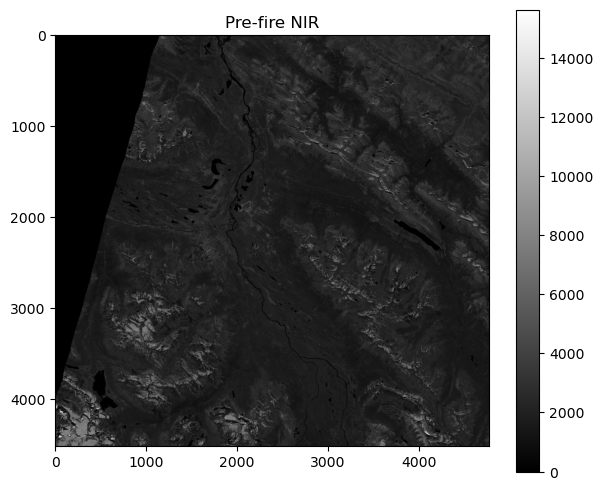

In [45]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(PRE_DIR / "pre_nir.tif") as src:
    arr = src.read(1)

print(arr.shape)

plt.figure(figsize=(7, 6))
plt.imshow(arr, cmap="gray")
plt.title("Pre-fire NIR")
plt.colorbar()
plt.show()

# What this image shows

- This is the Near-Infrared (NIR) band (Band 8) of a Sentinel-2 scene captured before the Jasper fire. 
- The image dimensions are 4,515 × 4,776 pixels at 10m resolution, meaning this tile covers approximately 45 × 48 km of terrain — more than enough to capture the entire Jasper Wildfire Complex footprint.

# Reading the image

- The bright areas (high NIR reflectance, values 8,000–14,000) are healthy dense vegetation — coniferous boreal forest, which is exactly what burned. NIR is highly sensitive to vegetation health, making it your most important band.

- The dark diagonal band running top-left to bottom-center is the Athabasca River valley — water absorbs NIR, so rivers and lakes appear nearly black.

- The upper-left black triangle is a no-data region outside the satellite swath — this is normal for Sentinel-2 tiles at scene edges, and you'll need to mask it out during preprocessing.

- The mid-toned rugged terrain in the lower half reflects the Rocky Mountain topography around Jasper National Park.

(4515, 4776)


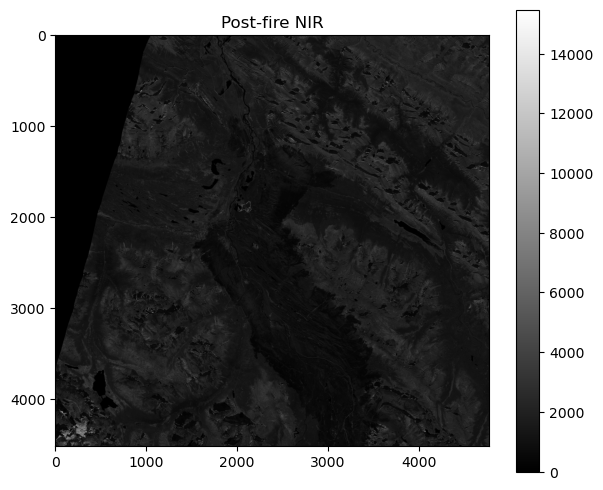

In [48]:
with rasterio.open(POST_DIR / "post_nir.tif") as src:
    arr = src.read(1)

print(arr.shape)

plt.figure(figsize=(7, 6))
plt.imshow(arr, cmap="gray")
plt.title("Post-fire NIR")
plt.colorbar()
plt.show()